# Walkthrough - Clustering Methods Compared

The point of this walkthrough is the lesson's central claim: **each algorithm encodes a
different definition of "cluster"**, and you can see the definitions fail on data that
violates them. We will:
1. Build four synthetic datasets, each friendly to a different algorithm.
2. Run k-means, GMM, DBSCAN, and agglomerative clustering on all of them.
3. Choose $k$ with the elbow, the silhouette, and BIC.
4. Read a dendrogram.

Companion lessons: Lessons 01-02 of this chapter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

RNG = np.random.default_rng(0)

## Part 1 - Four datasets, four cluster definitions

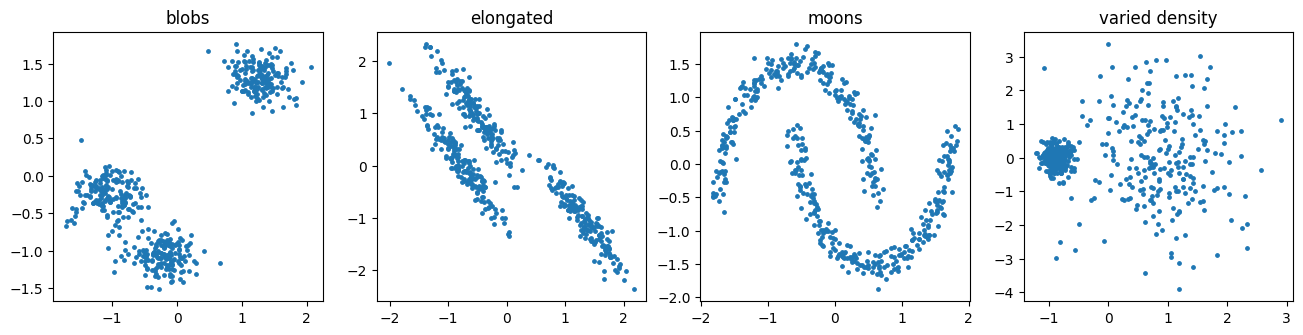

In [2]:
n = 500
datasets = {}

datasets["blobs"], _ = make_blobs(n_samples=n, centers=3, random_state=1)

X_aniso, _ = make_blobs(n_samples=n, centers=3, random_state=170)
datasets["elongated"] = X_aniso @ np.array([[0.6, -0.6], [-0.4, 0.8]])  # linear skew

datasets["moons"], _ = make_moons(n_samples=n, noise=0.06, random_state=0)

X_dense, _ = make_blobs(n_samples=n // 2, centers=[[0, 0]], cluster_std=0.3, random_state=0)
X_sparse, _ = make_blobs(n_samples=n // 2, centers=[[4, 0]], cluster_std=1.6, random_state=1)
datasets["varied density"] = np.vstack([X_dense, X_sparse])

datasets = {name: StandardScaler().fit_transform(X) for name, X in datasets.items()}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (name, X) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], s=6)
    ax.set_title(name)
plt.show()

## Part 2 - Every algorithm on every dataset

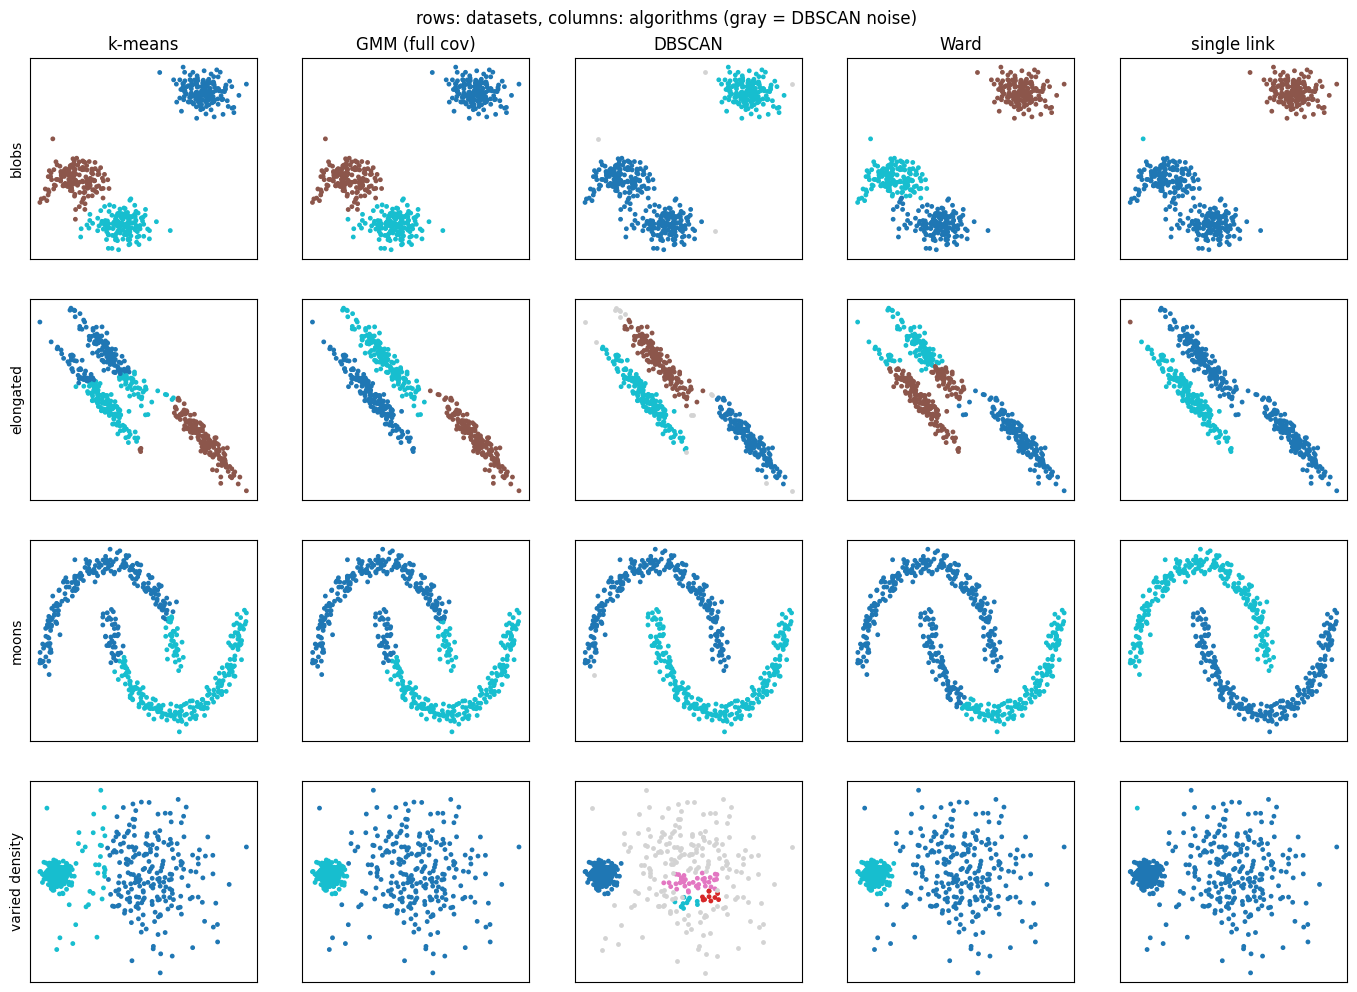

In [3]:
def get_models(k):
    return {
        "k-means": KMeans(n_clusters=k, n_init=10, random_state=0),
        "GMM (full cov)": GaussianMixture(n_components=k, covariance_type="full", random_state=0),
        "DBSCAN": DBSCAN(eps=0.25, min_samples=10),
        "Ward": AgglomerativeClustering(n_clusters=k, linkage="ward"),
        "single link": AgglomerativeClustering(n_clusters=k, linkage="single"),
    }

k_per_dataset = {"blobs": 3, "elongated": 3, "moons": 2, "varied density": 2}

fig, axes = plt.subplots(4, 5, figsize=(17, 12))
for i, (dname, X) in enumerate(datasets.items()):
    for j, (mname, model) in enumerate(get_models(k_per_dataset[dname]).items()):
        labels = model.fit_predict(X) if hasattr(model, "fit_predict") else model.fit(X).predict(X)
        ax = axes[i, j]
        noise = labels == -1
        ax.scatter(X[~noise, 0], X[~noise, 1], c=labels[~noise], cmap="tab10", s=6)
        ax.scatter(X[noise, 0], X[noise, 1], c="lightgray", s=6)  # DBSCAN noise in gray
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(mname)
        if j == 0:
            ax.set_ylabel(dname, fontsize=10)
plt.suptitle("rows: datasets, columns: algorithms (gray = DBSCAN noise)", y=0.92)
plt.show()

Read the grid against the lessons:

* **k-means** wins on blobs, cuts the elongated clusters wrongly (spherical assumption),
  slices the moons with a straight line, and splits the dense/sparse pair by distance, not density.
* **GMM** fixes the elongated case (full covariances) but still assumes "one Gaussian blob per cluster" - moons defeat it.
* **DBSCAN** nails the moons and marks outliers as noise, but one global $\varepsilon$
  struggles on the varied-density pair (the sparse cluster shatters into noise).
* **Ward** behaves like a nested k-means; **single linkage** is connectivity - great on moons, chains elsewhere.

## Part 3 - Choosing k: elbow, silhouette, BIC

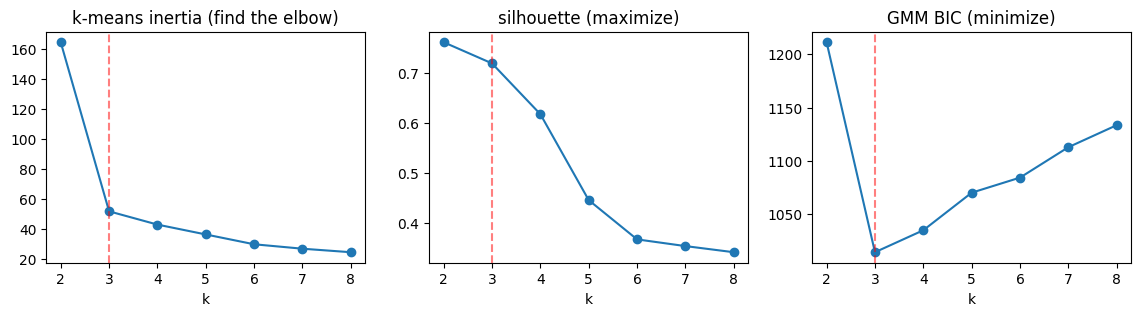

In [4]:
X = datasets["blobs"]
ks = range(2, 9)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(X).inertia_ for k in ks]
silhouettes = [silhouette_score(X, KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)) for k in ks]
bics = [GaussianMixture(n_components=k, random_state=0).fit(X).bic(X) for k in ks]

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].plot(ks, inertias, "o-"); axes[0].set_title("k-means inertia (find the elbow)")
axes[1].plot(ks, silhouettes, "o-"); axes[1].set_title("silhouette (maximize)")
axes[2].plot(ks, bics, "o-"); axes[2].set_title("GMM BIC (minimize)")
for ax in axes:
    ax.set_xlabel("k")
    ax.axvline(3, color="r", ls="--", alpha=0.5)
plt.show()

All three point at $k=3$ here - on real data they will disagree, and that disagreement
is itself information about how blob-like your data actually is.

## Part 4 - The dendrogram

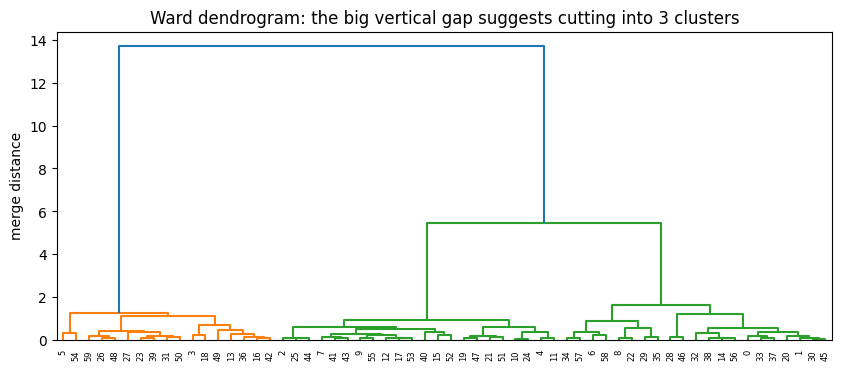

In [5]:
X = datasets["blobs"][:60]  # subsample so the tree is readable
Z = linkage(X, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z)
plt.title("Ward dendrogram: the big vertical gap suggests cutting into 3 clusters")
plt.ylabel("merge distance")
plt.show()

### TODO exercises

1. DBSCAN's $\varepsilon$: for the moons dataset, plot the sorted distance of each point to its
   10th nearest neighbor (`sklearn.neighbors.NearestNeighbors`) and place $\varepsilon$ at the elbow.
   Refit and compare with our hand-picked 0.25.
2. Compute the silhouette score of DBSCAN's moons clustering and of k-means' - the *wrong*
   clustering scores higher. Explain why (which cluster definition does the silhouette reward?).
3. Fit `GaussianMixture(covariance_type="spherical")` on the elongated data - you should
   recover k-means-like failures. Why?
4. On the varied-density dataset, try `HDBSCAN` (sklearn >= 1.3: `sklearn.cluster.HDBSCAN`) and
   check whether it fixes DBSCAN's single-threshold problem.
5. Cut the dendrogram at several heights with `scipy.cluster.hierarchy.fcluster` and plot the
   resulting partitions.